# 第5章: 離散型分布

## 学習目標
- 主要な離散型分布のパラメータと性質を理解する
- 各分布の期待値、分散、母関数を計算できる
- 分布間の関係を理解する
- 実際のデータに適用できるようになる

## 📋 学習メタ情報

### 学習目標
（既存の学習目標を活用）

### 推定学習時間
**90〜120分**

### 難易度
**★★☆☆☆** (5段階中2)

---

## 🎯 なぜこの章を学ぶのか？

離散型分布は、カウントデータ（顧客数、不良品数、クリック数など）のモデリングに不可欠です。ベルヌーイ、二項、ポアソン、幾何分布などは、実務で最も頻繁に使われる分布です。

### 実世界での応用

**ウェブサイトのクリック数**: ポアソン分布でモデリングし、適切なサーバー容量を設計

**製品の不良品検査**: 二項分布を使って、ロット全体の不良率を推定

**待ち時間のモデリング**: 幾何分布で、成功するまでの試行回数を予測

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 5.1 ベルヌーイ分布と二項分布

### ベルヌーイ分布 Ber(p)
- $P(X = 1) = p$, $P(X = 0) = 1 - p$
- $E[X] = p$, $Var(X) = p(1-p)$
- $M_X(t) = 1 - p + pe^t$

### 二項分布 Bin(n, p)
- $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$
- $E[X] = np$, $Var(X) = np(1-p)$
- $M_X(t) = (1 - p + pe^t)^n$
- ベルヌーイ試行のn回の和

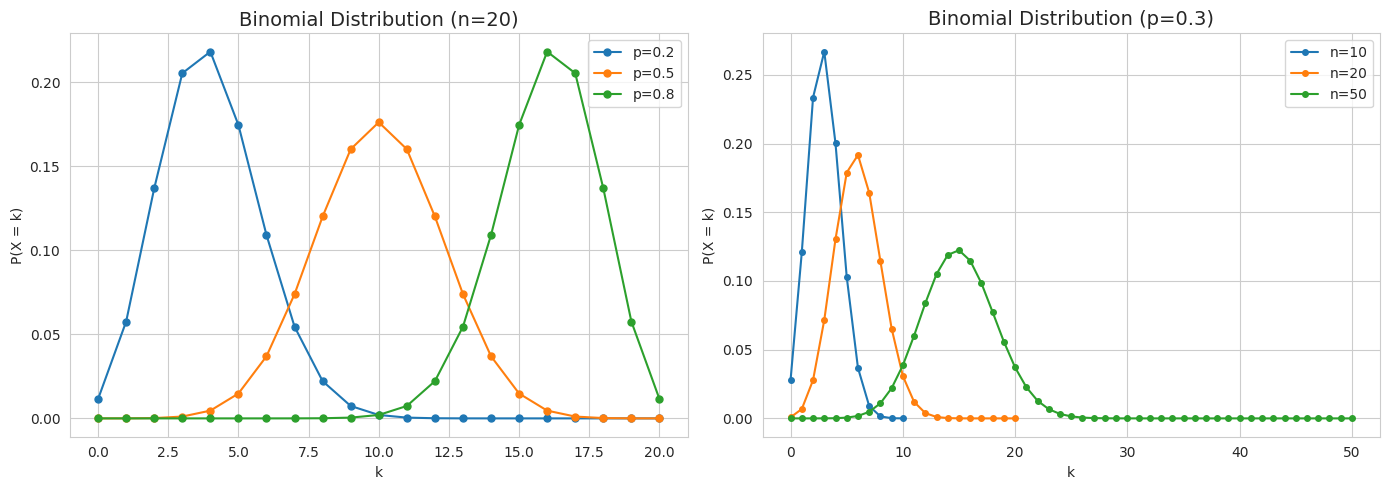

In [2]:
# 二項分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n = 20
x = np.arange(0, n + 1)

# 異なるpでの比較
for p in [0.2, 0.5, 0.8]:
    pmf = stats.binom.pmf(x, n, p)
    axes[0].plot(x, pmf, 'o-', label=f'p={p}', markersize=5)

axes[0].set_title(f'Binomial Distribution (n={n})', fontsize=14)
axes[0].set_xlabel('k')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()

# 異なるnでの比較（p固定）
p = 0.3
for n_val in [10, 20, 50]:
    x_val = np.arange(0, n_val + 1)
    pmf = stats.binom.pmf(x_val, n_val, p)
    axes[1].plot(x_val, pmf, 'o-', label=f'n={n_val}', markersize=4)

axes[1].set_title(f'Binomial Distribution (p={p})', fontsize=14)
axes[1].set_xlabel('k')
axes[1].set_ylabel('P(X = k)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
# 二項分布のシミュレーション
n, p = 20, 0.3
n_samples = 100000

# 方法1: scipy.stats
samples_scipy = np.random.binomial(n, p, n_samples)

# 方法2: ベルヌーイの和
bernoulli = np.random.binomial(1, p, (n_samples, n))
samples_sum = np.sum(bernoulli, axis=1)

print(f"二項分布 Bin({n}, {p}) の統計量")
print("="*50)
print(f"理論平均: {n*p:.4f}, シミュレーション: {np.mean(samples_scipy):.4f}")
print(f"理論分散: {n*p*(1-p):.4f}, シミュレーション: {np.var(samples_scipy):.4f}")

二項分布 Bin(20, 0.3) の統計量
理論平均: 6.0000, シミュレーション: 5.9955
理論分散: 4.2000, シミュレーション: 4.1769


## 5.2 ポアソン分布

### 定義
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, ...$$

### 性質
- $E[X] = \lambda$
- $Var(X) = \lambda$
- $M_X(t) = \exp(\lambda(e^t - 1))$

### 重要な関係
- 二項分布の極限: $n \to \infty$, $p \to 0$, $np = \lambda$ のとき $Bin(n, p) \to Poi(\lambda)$
- ポアソン過程: 単位時間あたり平均λ回起こる事象の回数

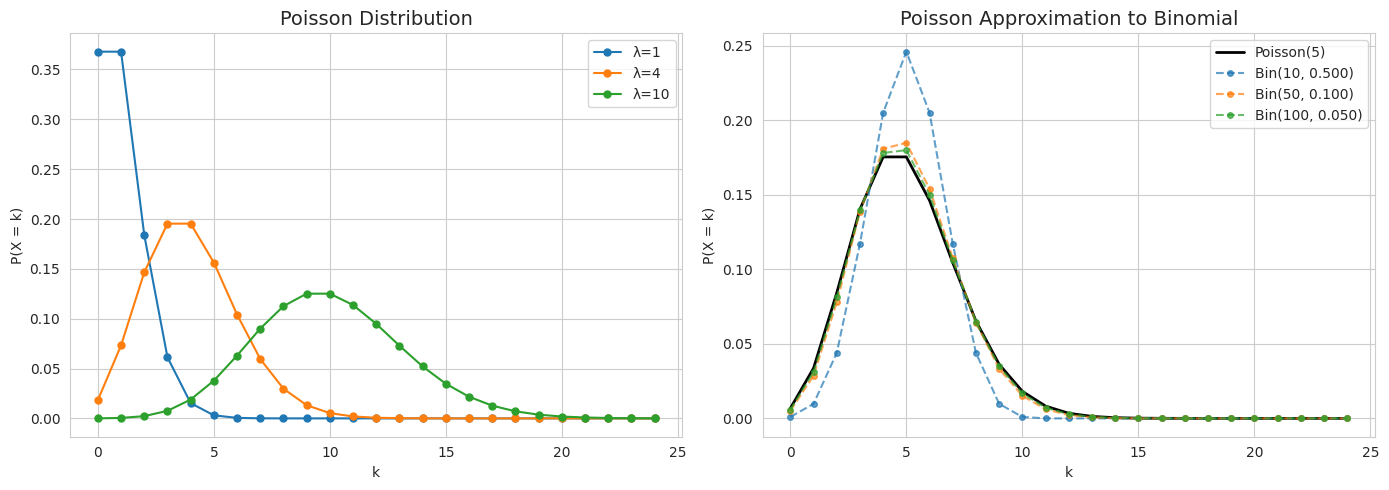

In [4]:
# ポアソン分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 異なるλでの比較
x = np.arange(0, 25)
for lam in [1, 4, 10]:
    pmf = stats.poisson.pmf(x, lam)
    axes[0].plot(x, pmf, 'o-', label=f'λ={lam}', markersize=5)

axes[0].set_title('Poisson Distribution', fontsize=14)
axes[0].set_xlabel('k')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()

# 二項分布からの近似
lam = 5
poisson_pmf = stats.poisson.pmf(x, lam)
axes[1].plot(x, poisson_pmf, 'k-', linewidth=2, label=f'Poisson({lam})')

for n in [10, 50, 100]:
    p = lam / n
    binom_pmf = stats.binom.pmf(x, n, p)
    axes[1].plot(x, binom_pmf, 'o--', label=f'Bin({n}, {p:.3f})', 
                 markersize=4, alpha=0.7)

axes[1].set_title('Poisson Approximation to Binomial', fontsize=14)
axes[1].set_xlabel('k')
axes[1].set_ylabel('P(X = k)')
axes[1].legend()

plt.tight_layout()
plt.show()

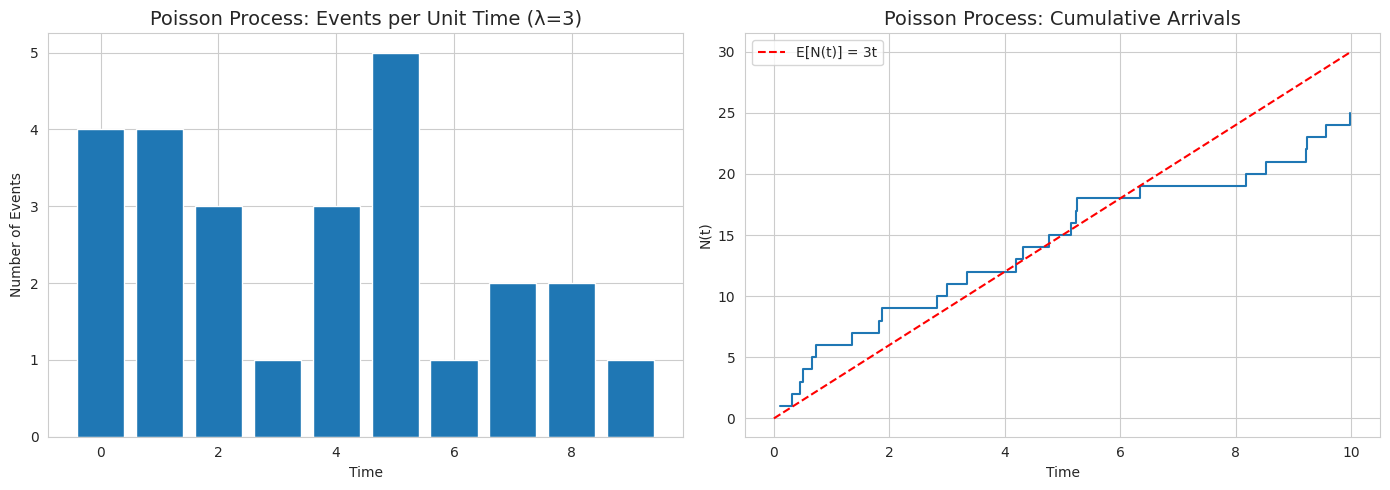

In [5]:
# ポアソン過程のシミュレーション
lam = 3  # 単位時間あたりの平均発生回数
T = 10   # 観測時間

# 方法1: 各時点での発生回数
arrivals = np.random.poisson(lam, T)

# 方法2: 到着間隔（指数分布）
inter_arrivals = np.random.exponential(1/lam, 100)
arrival_times = np.cumsum(inter_arrivals)
arrival_times = arrival_times[arrival_times < T]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 各時点の発生回数
axes[0].bar(range(T), arrivals)
axes[0].set_title(f'Poisson Process: Events per Unit Time (λ={lam})', fontsize=14)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Number of Events')

# 累積プロット
cumulative = np.arange(1, len(arrival_times) + 1)
axes[1].step(arrival_times, cumulative, where='post')
axes[1].plot([0, T], [0, lam * T], 'r--', label=f'E[N(t)] = {lam}t')
axes[1].set_title('Poisson Process: Cumulative Arrivals', fontsize=14)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('N(t)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5.3 幾何分布と負の二項分布

### 幾何分布 Geo(p)
最初の成功までの失敗回数:
- $P(X = k) = (1-p)^k p$, $k = 0, 1, 2, ...$
- $E[X] = \frac{1-p}{p}$
- $Var(X) = \frac{1-p}{p^2}$

### 負の二項分布 NB(r, p)
r回成功するまでの失敗回数:
- $P(X = k) = \binom{k+r-1}{k} p^r (1-p)^k$
- $E[X] = \frac{r(1-p)}{p}$
- $Var(X) = \frac{r(1-p)}{p^2}$
- 幾何分布はr=1の負の二項分布

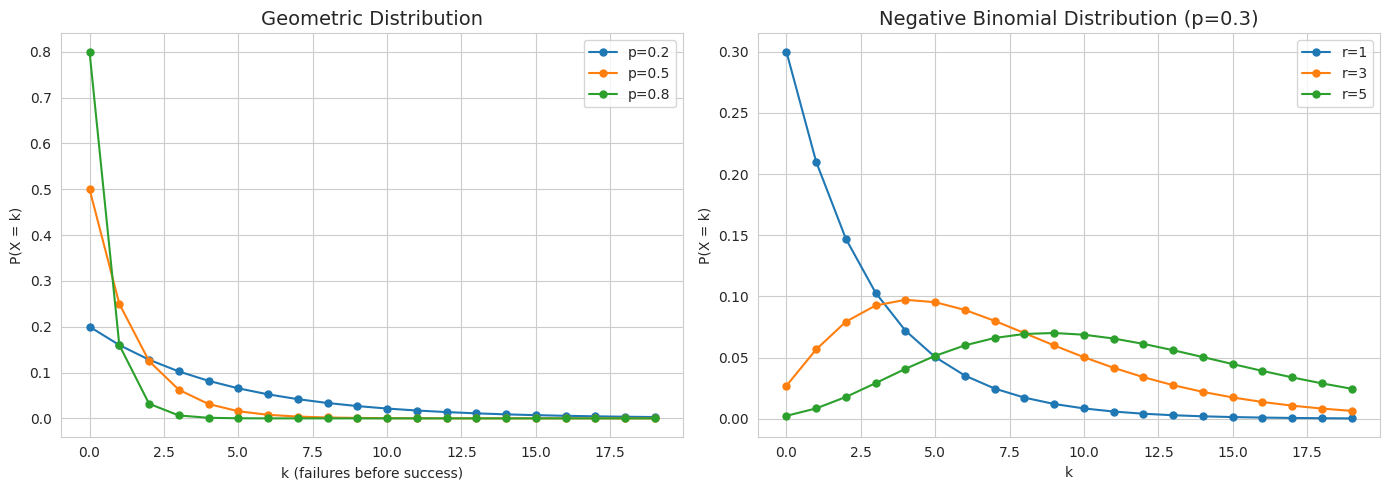

In [6]:
# 幾何分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(0, 20)

# 異なるpでの幾何分布
for p in [0.2, 0.5, 0.8]:
    pmf = stats.geom.pmf(x + 1, p)  # scipy.statsは1からカウント
    axes[0].plot(x, pmf, 'o-', label=f'p={p}', markersize=5)

axes[0].set_title('Geometric Distribution', fontsize=14)
axes[0].set_xlabel('k (failures before success)')
axes[0].set_ylabel('P(X = k)')
axes[0].legend()

# 負の二項分布
p = 0.3
for r in [1, 3, 5]:
    pmf = stats.nbinom.pmf(x, r, p)
    axes[1].plot(x, pmf, 'o-', label=f'r={r}', markersize=5)

axes[1].set_title(f'Negative Binomial Distribution (p={p})', fontsize=14)
axes[1].set_xlabel('k')
axes[1].set_ylabel('P(X = k)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# 無記憶性の確認（幾何分布の特性）
p = 0.3
n_samples = 100000

X = np.random.geometric(p, n_samples)  # 成功までの試行回数

# P(X > s + t | X > s) = P(X > t)
s = 3
t = 2

# 条件付き確率
X_greater_s = X[X > s]
P_cond = np.mean(X_greater_s > s + t)

# 無条件確率
P_uncond = np.mean(X > t)

print("幾何分布の無記憶性")
print("="*50)
print(f"P(X > {s}+{t} | X > {s}) = {P_cond:.4f}")
print(f"P(X > {t}) = {P_uncond:.4f}")
print(f"\n理論値: (1-p)^t = {(1-p)**t:.4f}")

幾何分布の無記憶性
P(X > 3+2 | X > 3) = 0.4906
P(X > 2) = 0.4895

理論値: (1-p)^t = 0.4900


## 5.4 超幾何分布

### 定義
N個中M個が当たりの中からn個を非復元抽出したときの当たりの数

$$P(X = k) = \frac{\binom{M}{k}\binom{N-M}{n-k}}{\binom{N}{n}}$$

### 性質
- $E[X] = n \cdot \frac{M}{N}$
- $Var(X) = n \cdot \frac{M}{N} \cdot \frac{N-M}{N} \cdot \frac{N-n}{N-1}$
- N が大きい時、二項分布に近づく

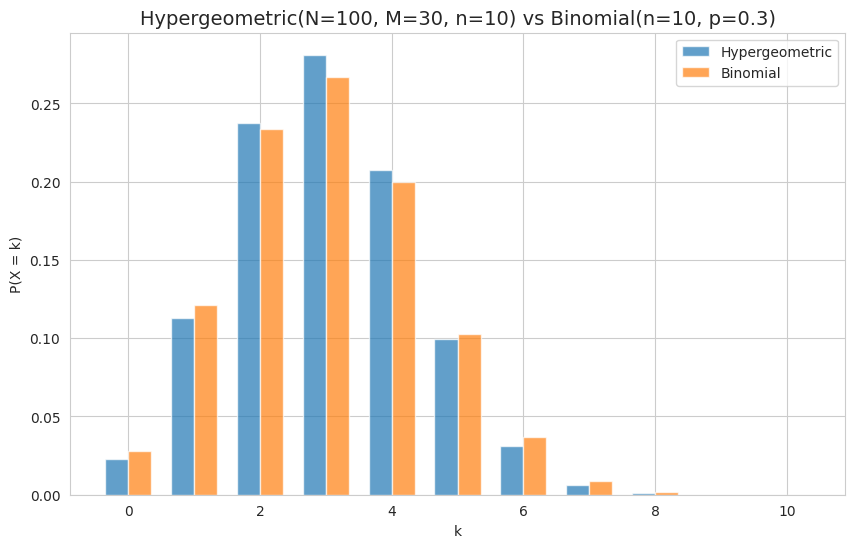

期待値（超幾何）: 3.0000
期待値（二項）: 3.0000
分散（超幾何）: 1.9091
分散（二項）: 2.1000


In [8]:
# 超幾何分布 vs 二項分布
N = 100  # 全体の数
M = 30   # 当たりの数
n = 10   # 抽出数

x = np.arange(0, n + 1)

# 超幾何分布
hypergeom_pmf = stats.hypergeom.pmf(x, N, M, n)

# 二項分布（近似）
p = M / N
binom_pmf = stats.binom.pmf(x, n, p)

fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
ax.bar(x - width/2, hypergeom_pmf, width, label='Hypergeometric', alpha=0.7)
ax.bar(x + width/2, binom_pmf, width, label='Binomial', alpha=0.7)

ax.set_title(f'Hypergeometric(N={N}, M={M}, n={n}) vs Binomial(n={n}, p={p})', 
             fontsize=14)
ax.set_xlabel('k')
ax.set_ylabel('P(X = k)')
ax.legend()

plt.show()

print(f"期待値（超幾何）: {stats.hypergeom.mean(N, M, n):.4f}")
print(f"期待値（二項）: {n * p:.4f}")
print(f"分散（超幾何）: {stats.hypergeom.var(N, M, n):.4f}")
print(f"分散（二項）: {n * p * (1-p):.4f}")

## 5.5 多項分布

### 定義
k種類の結果がある試行をn回行ったときの各結果の回数

$$P(X_1=n_1, ..., X_k=n_k) = \frac{n!}{n_1! \cdots n_k!} p_1^{n_1} \cdots p_k^{n_k}$$

### 性質
- $E[X_i] = np_i$
- $Var(X_i) = np_i(1-p_i)$
- $Cov(X_i, X_j) = -np_ip_j$ (i ≠ j)

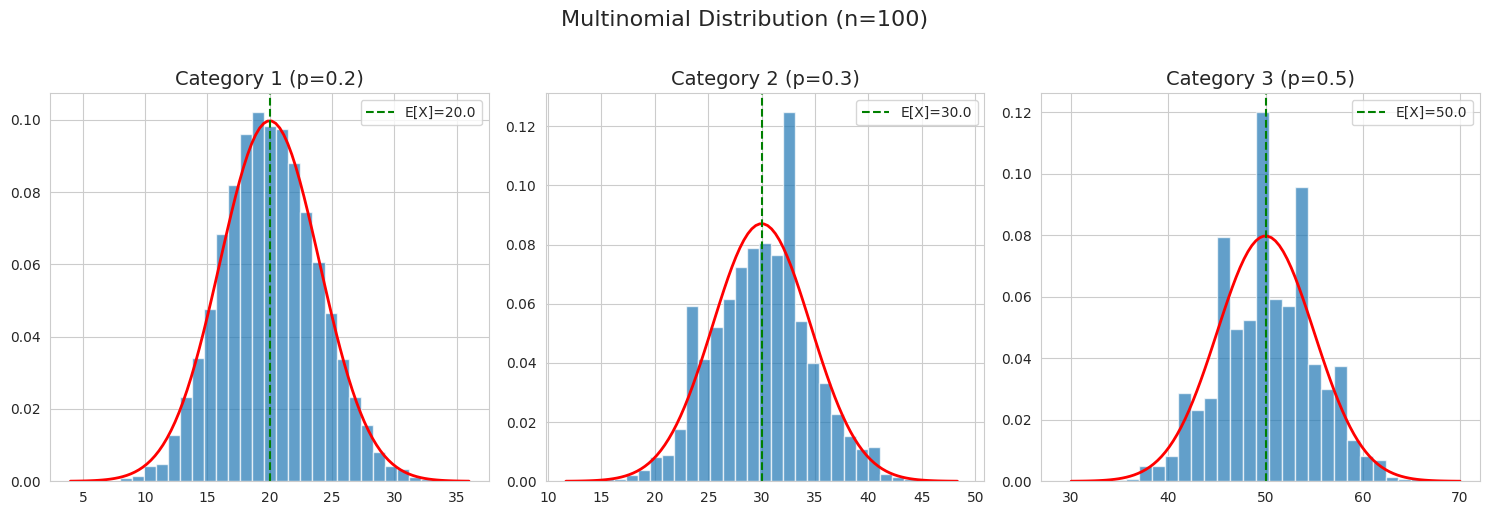

多項分布の共分散
Cov(X1, X2): theory=-6.00, sim=-6.07
Cov(X1, X3): theory=-10.00, sim=-9.74
Cov(X2, X3): theory=-15.00, sim=-14.45


In [9]:
# 多項分布のシミュレーション
n = 100  # 試行回数
p = [0.2, 0.3, 0.5]  # 各カテゴリの確率
n_samples = 10000

samples = np.random.multinomial(n, p, n_samples)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

categories = ['Category 1', 'Category 2', 'Category 3']

for i, (cat, prob) in enumerate(zip(categories, p)):
    axes[i].hist(samples[:, i], bins=30, density=True, alpha=0.7)
    
    # 正規近似
    mean_i = n * prob
    var_i = n * prob * (1 - prob)
    x_range = np.linspace(mean_i - 4*np.sqrt(var_i), mean_i + 4*np.sqrt(var_i), 100)
    axes[i].plot(x_range, stats.norm.pdf(x_range, mean_i, np.sqrt(var_i)), 
                 'r-', linewidth=2)
    
    axes[i].set_title(f'{cat} (p={prob})', fontsize=14)
    axes[i].axvline(mean_i, color='g', linestyle='--', label=f'E[X]={mean_i}')
    axes[i].legend()

plt.suptitle(f'Multinomial Distribution (n={n})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 共分散の確認
print("多項分布の共分散")
print("="*50)
for i in range(3):
    for j in range(i+1, 3):
        cov_theory = -n * p[i] * p[j]
        cov_sim = np.cov(samples[:, i], samples[:, j])[0, 1]
        print(f"Cov(X{i+1}, X{j+1}): theory={cov_theory:.2f}, sim={cov_sim:.2f}")

## 5.6 分布間の関係まとめ

In [10]:
# 分布間の関係の可視化
print("離散型分布の関係")
print("="*60)
print()
print("1. ベルヌーイ分布の和 → 二項分布")
print("   X₁, ..., Xₙ ~ iid Ber(p) → Σ Xᵢ ~ Bin(n, p)")
print()
print("2. 二項分布の極限 → ポアソン分布")
print("   Bin(n, p), n→∞, p→0, np=λ → Poi(λ)")
print()
print("3. 幾何分布の和 → 負の二項分布")
print("   X₁, ..., Xᵣ ~ iid Geo(p) → Σ Xᵢ ~ NB(r, p)")
print()
print("4. ポアソン分布の和 → ポアソン分布")
print("   X ~ Poi(λ₁), Y ~ Poi(λ₂) → X+Y ~ Poi(λ₁+λ₂)")
print()
print("5. 超幾何分布の極限 → 二項分布")
print("   N→∞, M/N=p → Bin(n, p)")

離散型分布の関係

1. ベルヌーイ分布の和 → 二項分布
   X₁, ..., Xₙ ~ iid Ber(p) → Σ Xᵢ ~ Bin(n, p)

2. 二項分布の極限 → ポアソン分布
   Bin(n, p), n→∞, p→0, np=λ → Poi(λ)

3. 幾何分布の和 → 負の二項分布
   X₁, ..., Xᵣ ~ iid Geo(p) → Σ Xᵢ ~ NB(r, p)

4. ポアソン分布の和 → ポアソン分布
   X ~ Poi(λ₁), Y ~ Poi(λ₂) → X+Y ~ Poi(λ₁+λ₂)

5. 超幾何分布の極限 → 二項分布
   N→∞, M/N=p → Bin(n, p)


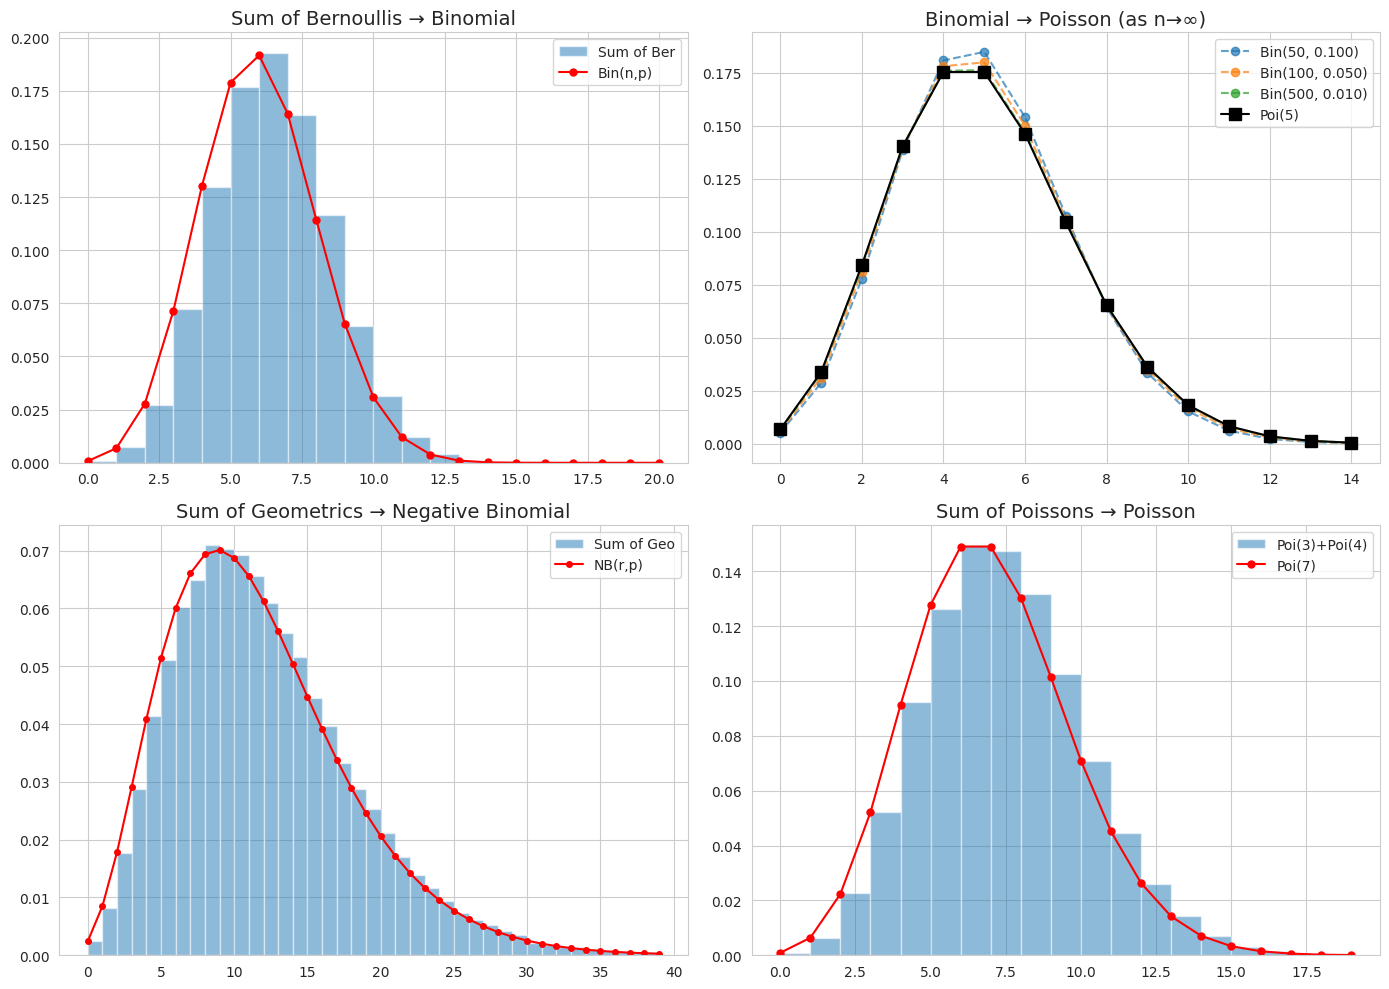

In [11]:
# 分布間の関係のシミュレーション
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_samples = 100000

# 1. ベルヌーイの和 → 二項
n, p = 20, 0.3
bernoulli_sum = np.sum(np.random.binomial(1, p, (n_samples, n)), axis=1)
binom_direct = np.random.binomial(n, p, n_samples)

x = np.arange(0, n + 1)
axes[0, 0].hist(bernoulli_sum, bins=x, density=True, alpha=0.5, label='Sum of Ber')
axes[0, 0].plot(x, stats.binom.pmf(x, n, p), 'ro-', markersize=5, label='Bin(n,p)')
axes[0, 0].set_title('Sum of Bernoullis → Binomial', fontsize=14)
axes[0, 0].legend()

# 2. 二項 → ポアソン（極限）
lam = 5
x = np.arange(0, 15)
for n in [50, 100, 500]:
    p = lam / n
    axes[0, 1].plot(x, stats.binom.pmf(x, n, p), 'o--', 
                    label=f'Bin({n}, {lam/n:.3f})', alpha=0.7)
axes[0, 1].plot(x, stats.poisson.pmf(x, lam), 'ks-', 
                markersize=8, label=f'Poi({lam})')
axes[0, 1].set_title('Binomial → Poisson (as n→∞)', fontsize=14)
axes[0, 1].legend()

# 3. 幾何の和 → 負の二項
r, p = 5, 0.3
geo_sum = np.sum(np.random.geometric(p, (n_samples, r)), axis=1) - r
nbinom_direct = np.random.negative_binomial(r, p, n_samples)

x = np.arange(0, 40)
axes[1, 0].hist(geo_sum, bins=x, density=True, alpha=0.5, label='Sum of Geo')
axes[1, 0].plot(x, stats.nbinom.pmf(x, r, p), 'ro-', markersize=4, label='NB(r,p)')
axes[1, 0].set_title('Sum of Geometrics → Negative Binomial', fontsize=14)
axes[1, 0].legend()

# 4. ポアソンの和 → ポアソン
lam1, lam2 = 3, 4
X = np.random.poisson(lam1, n_samples)
Y = np.random.poisson(lam2, n_samples)
Z = X + Y

x = np.arange(0, 20)
axes[1, 1].hist(Z, bins=x, density=True, alpha=0.5, label=f'Poi({lam1})+Poi({lam2})')
axes[1, 1].plot(x, stats.poisson.pmf(x, lam1 + lam2), 'ro-', 
                markersize=5, label=f'Poi({lam1+lam2})')
axes[1, 1].set_title('Sum of Poissons → Poisson', fontsize=14)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5.7 練習問題

### 問題1
不良品率が5%の製品から10個を抽出するとき、不良品が2個以上含まれる確率を求めよ。

### 問題2
ある交差点で1時間あたり平均3件の事故が起こる。2時間で事故が5件以上起こる確率を求めよ。

### 問題3
成功確率0.2のベルヌーイ試行で、3回成功するまでに必要な試行回数の期待値と分散を求めよ。

In [12]:
# 問題1の解答
print("問題1の解答: 二項分布")
print("="*50)

n, p = 10, 0.05

# P(X ≥ 2) = 1 - P(X ≤ 1)
prob = 1 - stats.binom.cdf(1, n, p)

print(f"X ~ Bin({n}, {p})")
print(f"P(X ≥ 2) = 1 - P(X ≤ 1)")
print(f"        = 1 - [P(X=0) + P(X=1)]")
print(f"        = 1 - [{stats.binom.pmf(0, n, p):.6f} + {stats.binom.pmf(1, n, p):.6f}]")
print(f"        = {prob:.6f}")
print(f"        ≈ {prob*100:.2f}%")

問題1の解答: 二項分布
X ~ Bin(10, 0.05)
P(X ≥ 2) = 1 - P(X ≤ 1)
        = 1 - [P(X=0) + P(X=1)]
        = 1 - [0.598737 + 0.315125]
        = 0.086138
        ≈ 8.61%


In [13]:
# 問題2の解答
print("問題2の解答: ポアソン分布")
print("="*50)

# 2時間での平均事故数
lam = 3 * 2  # = 6

# P(X ≥ 5) = 1 - P(X ≤ 4)
prob = 1 - stats.poisson.cdf(4, lam)

print(f"X ~ Poi({lam})")
print(f"P(X ≥ 5) = 1 - P(X ≤ 4)")
print(f"        = {prob:.6f}")
print(f"        ≈ {prob*100:.2f}%")

問題2の解答: ポアソン分布
X ~ Poi(6)
P(X ≥ 5) = 1 - P(X ≤ 4)
        = 0.714943
        ≈ 71.49%


In [14]:
# 問題3の解答
print("問題3の解答: 負の二項分布")
print("="*50)

r, p = 3, 0.2

# 試行回数 = 成功回数 + 失敗回数
# 失敗回数 X ~ NB(r, p)
# E[X] = r(1-p)/p
# 試行回数 N = X + r

E_failures = r * (1 - p) / p
E_trials = E_failures + r

Var_failures = r * (1 - p) / p**2
Var_trials = Var_failures  # 定数の加算は分散を変えない

print(f"r={r}回成功するまでの失敗回数 X ~ NB({r}, {p})")
print(f"\nE[X] = r(1-p)/p = {E_failures:.2f}")
print(f"E[試行回数] = E[X] + r = {E_trials:.2f}")
print(f"\nVar(X) = r(1-p)/p² = {Var_failures:.2f}")
print(f"Var(試行回数) = {Var_trials:.2f}")

# シミュレーションで確認
n_samples = 100000
failures = np.random.negative_binomial(r, p, n_samples)
trials = failures + r

print(f"\nシミュレーション確認:")
print(f"E[試行回数] = {np.mean(trials):.2f}")
print(f"Var(試行回数) = {np.var(trials):.2f}")

問題3の解答: 負の二項分布
r=3回成功するまでの失敗回数 X ~ NB(3, 0.2)

E[X] = r(1-p)/p = 12.00
E[試行回数] = E[X] + r = 15.00

Var(X) = r(1-p)/p² = 60.00
Var(試行回数) = 60.00

シミュレーション確認:
E[試行回数] = 15.01
Var(試行回数) = 60.36


## ⚠️ よくある間違いと解決策

### ❌ ポアソン近似の誤用
**正しい理解:** n大、p小のときのみ二項→ポアソン近似が有効
**解決策:** np=λが適度な値（通常10程度）を確認

### ❌ 負の二項分布の解釈
**正しい理解:** r回成功までの失敗回数と、r回失敗までの成功回数の定義が混在
**解決策:** 教科書・ライブラリの定義を確認

---

## 📝 理解度チェッククイズ

### 問題 1
二項分布Bin(n,p)でn→∞, p→0, np→λのとき何が起こるか？

### 問題 2
ポアソン分布の分散と平均の関係は？

---

## 📚 まとめ

お疲れ様でした！この章で学んだ内容は、今後の章で繰り返し使います。

---